Cálculo de la función de correlación de pares $g(r)$ normalizada

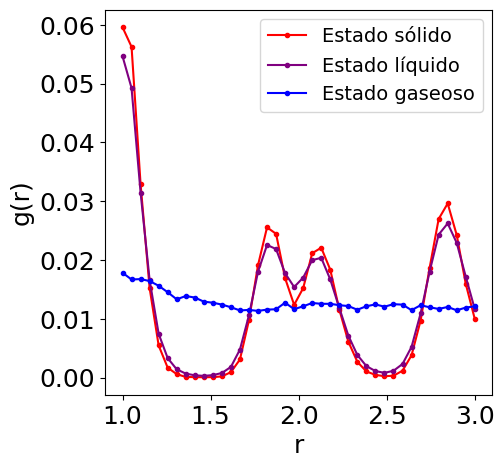

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cargo los datos
histograma_solido = np.loadtxt('Histograma_solido_ej_8.txt')
histograma_liquido = np.loadtxt('Histograma_liquido_ej_8.txt')
histograma_gas = np.loadtxt('Histograma_gas_ej_8.txt')

# Defino el rango de r, y el número de bins en los que se divide
r = np.linspace(1.0, 3.0, 40)

# ********************Es necesario normalizar el histograma para obtener la dunción de distribución ******************

#Se ha de dividir entre el área de la corona circular (2*pi*r*dr) y entre el número total de partículas detectadas, 
# al ser el area el 2 pi dr el mismo para cada bin, se omite dicha constante y se normaliza dividiendo entre el número 
# total de partículas detectadas, que es la suma de todos los bins del histograma.

g_solido = histograma_solido / (r * np.sum(histograma_solido))
g_liquido = histograma_liquido / (r * np.sum(histograma_liquido))
g_gas = histograma_gas / (r * np.sum(histograma_gas))

#********************************************** Grafico************************************************************
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(r, g_solido, color='red', label = 'Estado sólido', marker = 'o', markersize = 3)
ax.plot(r, g_liquido, color='purple', label = 'Estado líquido', marker = 'o', markersize = 3)
ax.plot(r, g_gas, color='blue', label = 'Estado gaseoso', marker = 'o', markersize = 3)
ax.set_xlabel('r', fontsize=18)
ax.set_ylabel('g(r)', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.legend(fontsize=14)

fig.savefig('ej_8.png', dpi=300, bbox_inches="tight")

Temperatura media del sistema en situación de equilibrio:
7.379312e+00


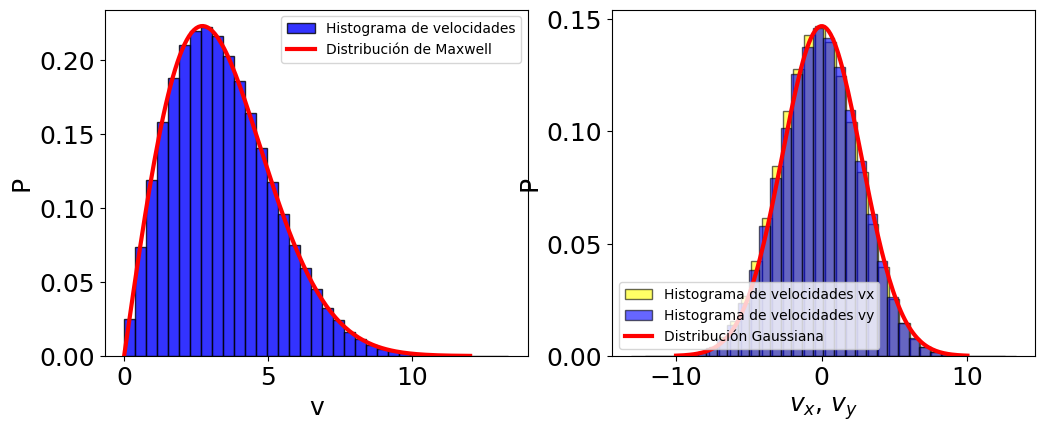

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#*************************************Calculo la temperatura media del sistema cuando se encuentra en equilibrio ***************************************

# Extraigo los datos de las velocidades 
Velocidades = np.loadtxt("Velocidades_atomos_ej_8.txt")


#Solo quiero promediar las velocidades de los átomos entre t=100 y t=250 segundos
#es decir, entre los indices 50000 y 125000 
v_x = Velocidades[50000:, 0::2]
v_y = Velocidades[50000:, 1::2]


#Temperatura media del sistema

T = 0.5 * np.mean(v_x**2 + v_y**2, axis = 1) # axis =1 indica que haga la media sobre las columnas
T_medio = np.mean(T)


print(f"Temperatura media del sistema en situación de equilibrio:\n{T_medio:e}")


#************************************************Hago las distribuciones**********************************************


#Módulo de la velocidad de cada átomo entre t = 100 y t=250 segundos
v = np.sqrt(v_x**2 + v_y**2)

# Transformo la matriz v en un vector. La dimension de v transformada en un vector es 75000*100 = 7500000 columnas
v = v.ravel()
v_x = v_x.ravel()
v_y = v_y.ravel()



# Función para calcular la distribución de Maxwell con la temperatura media del sistema obtenida antes
def distribucion_Maxwell(v, T):
    P = (1.0 / T) * v * np.exp(-v**2 / (2.0 * T))
    return P

v_teorica = np.linspace(0, 12.0, 150)
dist_Maxwell = distribucion_Maxwell(v_teorica, T_medio)


#Funcion para calcular la distribución Gaussiana con la temperatura media del sistema obtenida antes
def distribucion_Gaussiana(v, T):
    P_g = np.sqrt(1.0 / (2.0 * np.pi * T)) * np.exp(-v**2 / (2.0 * T))
    return P_g

v_x_y_teorica = np.linspace(-10.0, 10.0, 150)
dist_Gaussiana = distribucion_Gaussiana(v_x_y_teorica, T_medio)


#**************Representación***************************************************

fig, ax = plt.subplots(1,2, figsize=(12, 4.5))

ax[0].set_xlabel("v", fontsize=18)
ax[0].set_ylabel("P", fontsize=18)
ax[0].hist(v, bins = 35, density = True, alpha = 0.8, edgecolor="black", label = "Histograma de velocidades", color = "blue")
ax[0].plot(v_teorica, dist_Maxwell, label = "Distribución de Maxwell", color = "red", linewidth = 3)
ax[0].tick_params(axis="both", labelsize=18)
ax[0].legend()

ax[1].hist(v_x, bins = 35, density = True, alpha = 0.6, edgecolor="black", label = "Histograma de velocidades vx", color = "yellow")
ax[1].hist(v_y, bins = 35, density = True, alpha = 0.6, edgecolor="black", color = "blue", label = "Histograma de velocidades vy")
ax[1].plot(v_x_y_teorica, dist_Gaussiana, label = "Distribución Gaussiana", color = "red", linewidth = 3)
ax[1].set_xlabel(r"$v_x$, $v_y$", fontsize=18)
ax[1].set_ylabel("P", fontsize=18)
ax[1].tick_params(axis="both", labelsize=18)
ax[1].legend(loc = "lower left")

fig.savefig("Histograma_velocidades_Lennard_Jones_ej_8.png", dpi=300, bbox_inches="tight")